14:38:36 KST Mode solver created with                                           
             task_id='fdve-dcd62164-eeee-46cf-aa76-c2bf44bcf613',               
             solver_id='mo-7f07e999-5c95-4afc-ab3c-2c9d5bd3515f'.

/Users/hwanghyeon/pattern/tidy/lib/python3.11/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

14:38:39 KST Mode solver status: queued

14:38:41 KST Mode solver status: running

14:38:50 KST Mode solver status: success

...

14:42:16 KST Mode solver created with                                           
             task_id='fdve-a2deb3ac-1613-41de-9ed7-e333e49611d4',               
             solver_id='mo-381c6a2e-5bd3-4cb8-b5b5-dde38deaae9a'.

/Users/hwanghyeon/pattern/tidy/lib/python3.11/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

14:42:20 KST Mode solver status: queued

14:42:22 KST Mode solver status: running

14:42:29 KST Mode solver status: success

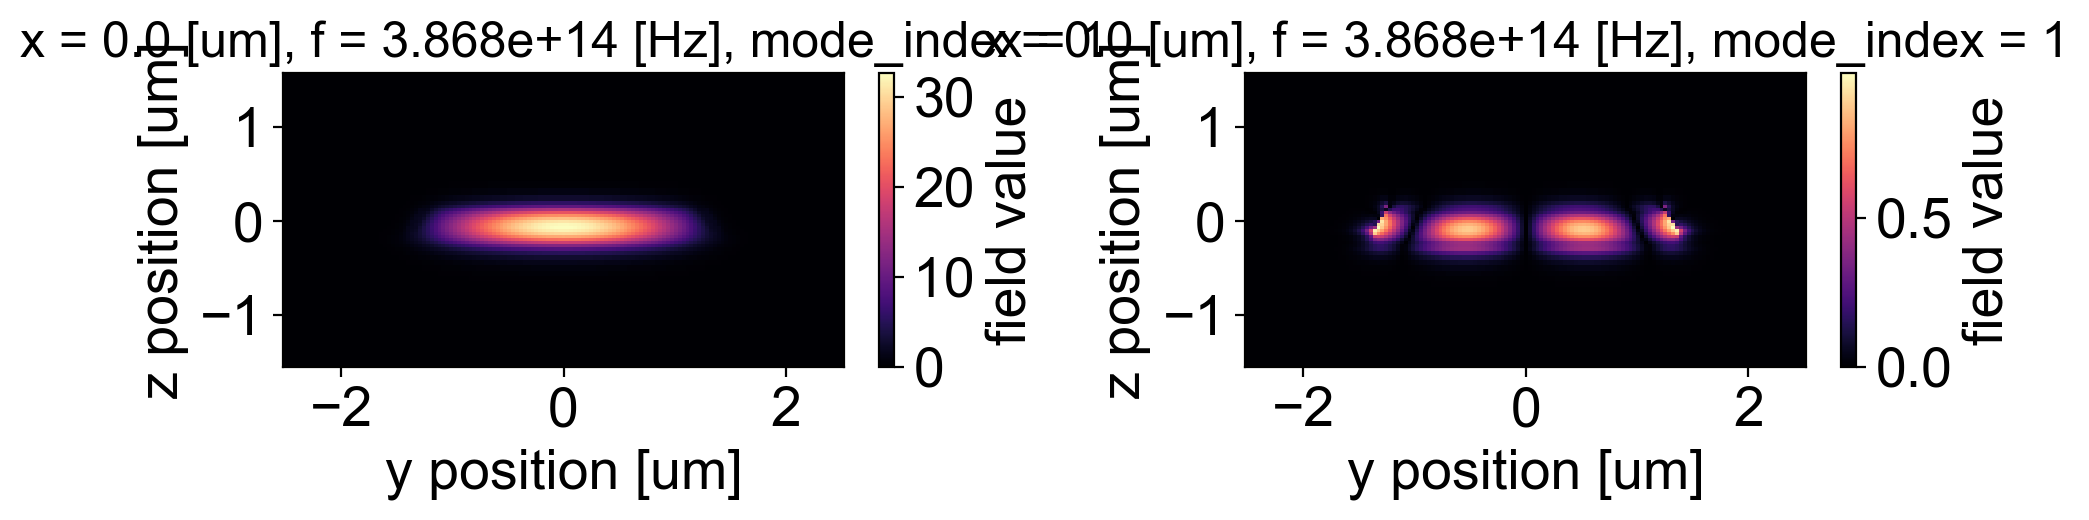

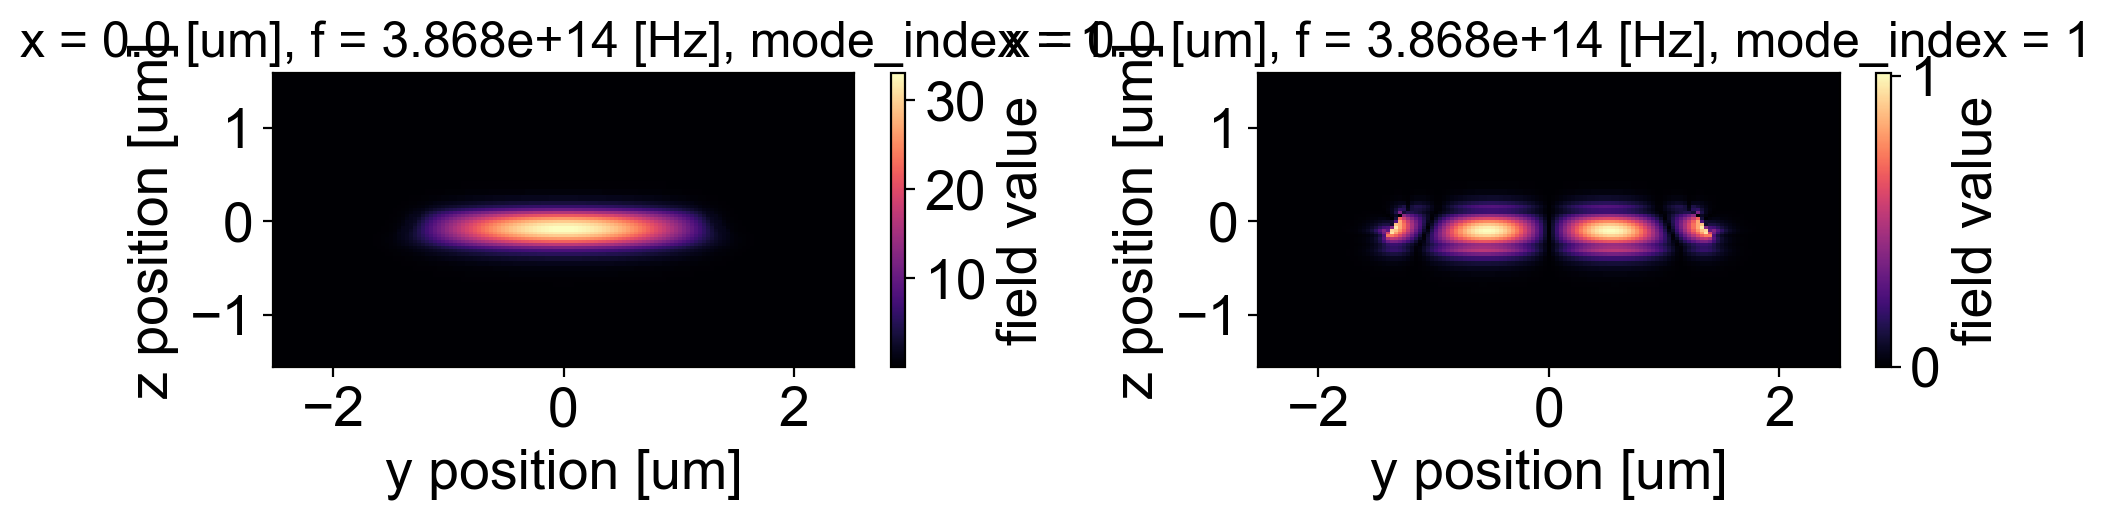

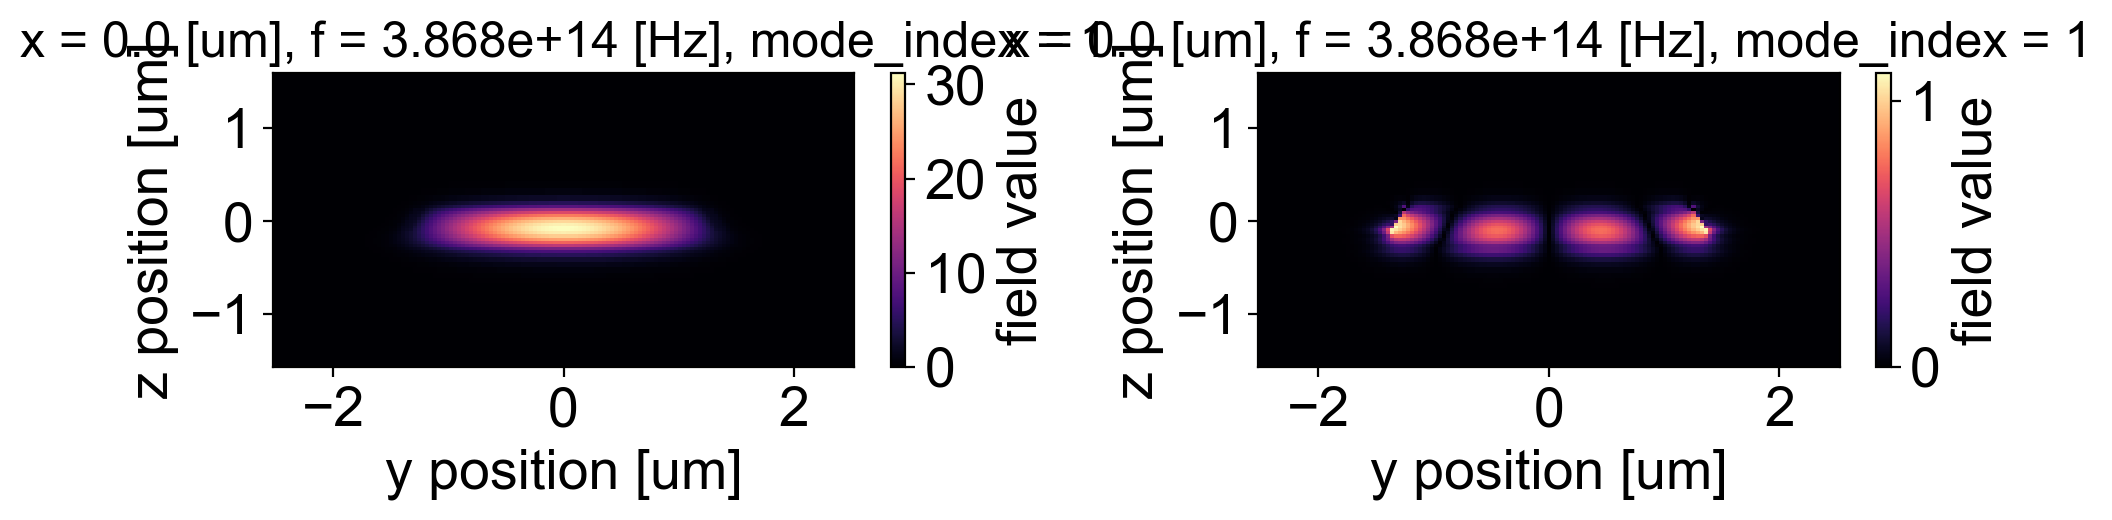

In [ ]:
# this code is for forming simiulation object.

# basic imports
import numpy as np
import matplotlib.pylab as plt

# Tidy3D imports
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.mode.web import run as run_mode_solver


# materials
eff_inf = 100
n_sio2 = 1.444  # silicon oxide refractive index at 1550 nm
air = td.Medium(permittivity=1)
ln_no_coeffs = [(2.6734, 0.01764), (1.2290, 0.05914), (12.614, 474.60)]
ln_ne_coeffs = [(2.9804, 0.02047),  (0.5981, 0.0666),  (8.9543, 416.08)]
sio2_coeffs = [(0.6961663, 0.0684),  (0.40794, 0.11624),  (0.8974794, 9.89616)]



ln_no= td.Sellmeier(coeffs=ln_no_coeffs)
ln_ne= td.Sellmeier(coeffs=ln_ne_coeffs)
sio2= td.Sellmeier(coeffs=sio2_coeffs)
ln = td.AnisotropicMedium(xx=ln_no, yy=ln_ne, zz=ln_no)
## source
wavelength0 = 1.55
freq0 = td.C_0 / wavelength0
fwidth = freq0 / 40.0
run_time = 5.0e-12
wavelength_min = td.C_0 / (freq0 + fwidth)


# 파라미터 설정
sidewall_angle=(90-60)*np.pi/180
Hc=0.25
Hs=(0.4-Hc)

      # 전체 길이
mnum=150
w_wg= 1.8
l=2
size_x=2*2+l
size_y=1.55*1.0+w_wg*2




# boundary conditions - Bloch boundaries are used to emulate an infinitely long grating
boundary_spec = td.BoundarySpec(
    # x=td.Boundary.bloch(bloch_vec=num_periods/2),
    x=td.Boundary.pml(),
    y=td.Boundary.pml(),
    z=td.Boundary.pml(),
)




# create monitors


def structure_set(Hc,Hs,w_wg,sidewall_angle):

    # 윗부분과 아랫부분의 좌표를 결합하여 다각형 형태의 꼭짓점 정의
    vertices =[(eff_inf,-w_wg/2),(-eff_inf,-w_wg/2),(-eff_inf,w_wg/2),(0,w_wg/2)]
    LN_grating = td.Structure(
        geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"), medium=ln
    )
    # ln slab
    ln_substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-eff_inf, -eff_inf, -Hc/2-Hs),
            rmax=(eff_inf, eff_inf, -Hc/2),
        ),
        medium=ln,
    )


    # SiO2 BOX layer.
    sio2_substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-eff_inf, -eff_inf, -eff_inf),
            rmax=(eff_inf, eff_inf, -Hc/2-Hs),
        ),
        medium=sio2,
    )

    # list of all structures
    structures = (
        [LN_grating,ln_substrate,sio2_substrate]
    )
    return structures



# list of all monitors

def sim_set(wavelength,Hc,Hs,w_wg,sidewall_angle):
    freq0 = td.C_0 / wavelength
    structures=structure_set(Hc,Hs,w_wg,sidewall_angle)
    # grid specification
    uniform = td.UniformGrid(dl=0.02)
    grid_spec = td.GridSpec.auto(min_steps_per_wvl=20)
    grid_spec_VIS = td.GridSpec.auto(min_steps_per_wvl=20)

    #grid_spec = td.GridSpec(grid_x=uniform, grid_y=uniform, grid_z=uniform, wavelength=1.55)
    #grid_spec_VIS = td.GridSpec(grid_x=uniform, grid_y=uniform, grid_z=uniform, wavelength=0.775)

    # mode source for waveguide 
    source1_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, amplitude=1)

    
    monitor_xy = td.FieldMonitor(
        center=[l/2, 0, 0],
        size=[l, 2 * wavelength0 + w_wg , 0],
        freqs=[freq0],
        name="fields_xy",
    )
    monitors=[monitor_xy]



    mode_src1 = td.ModeSource(
        center=[0, 0, 0],
        size=[0, w_wg * 2, 3],
        mode_index=0,
        direction="+",
        source_time=source1_time,
        mode_spec=td.ModeSpec(),
    )
    # list of all sources
    sources = [mode_src1]
    # create the simulation
    sim = td.Simulation(

        center=(l/2, 0, 0),
        size=(size_x, size_y, Hc+Hs+3),
        grid_spec=grid_spec,
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        symmetry=(0, -1, 0),
    )

    sim2 = td.Simulation(

        center=(l/2, 0, 0),
        size=(size_x, size_y, Hc+Hs+3),
        grid_spec=grid_spec_VIS,
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        symmetry=(0, -1, 0),
    )

    return sim,sim2

### we are interested in QPM from 1550 nm to 775 nm
wavelength=1.55
Hnum=5
Wnum=5
thickness_set=np.linspace(0.38,0.42,Hnum)
#thickness_set=[0.38,0.4,0.42]
Wavelength_set=np.linspace(1.5,1.6,Wnum)
freqs = td.C_0 / Wavelength_set
k_set=np.zeros((Hnum,Wnum))
poling_set=np.zeros((Hnum,Wnum))
n1_set=np.zeros((Hnum,Wnum))
n2_set=np.zeros((Hnum,Wnum))
Hc=0.25 #etching depth
sidewall_angle=(90-60)*np.pi/180
width=2.5

####

mode_spec = td.ModeSpec(
    num_modes=5,
    target_neff=2.2,
)
wl_VIS = 0.775
freq0 = td.C_0 / wl_VIS

index_set=np.zeros((Hnum,1))
for i, Hln in enumerate(thickness_set):
    Hs=Hln-Hc

    [sim,sim2]=sim_set(wavelength,Hc,Hs,w_wg=width,sidewall_angle=sidewall_angle)

    # Modal source plane
    source_plane1 = td.Box(center=[0, 0, 0], size=[0, 5, 3])
    source_plane2 = td.Box(center=[0, 0, 0], size=[0, 3, 1.5])

    mode_spec = td.ModeSpec(
        num_modes=5,
        target_neff=2.1,
    )
    # NB: negative radius since the plane position is at y=-radius
    ms2 = ModeSolver(simulation=sim2, plane=source_plane1, freqs=freq0, mode_spec=mode_spec)
    mode_data = ms2.solve()

    index_set=mode_data.pol_fraction.te.squeeze().values # convert into numpy array
    index = np.argmax(index_set> 0.8)
    f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
    f0_ind = 0
    abs(mode_data.Ey.isel(mode_index=index, f=f0_ind)).plot(x="y", y="z", ax=ax1, cmap="magma")
    abs(mode_data.Ez.isel(mode_index=index, f=f0_ind)).plot(x="y", y="z", ax=ax2, cmap="magma")
    index_set[i]=index




###
for i, Hln in enumerate(thickness_set):
    Hs=Hln-Hc

    [sim,sim2]=sim_set(wavelength,Hc,Hs,w_wg=width,sidewall_angle=sidewall_angle)

    # Modal source plane
    source_plane1 = td.Box(center=[0, 0, 0], size=[0, 5, 3])
    source_plane2 = td.Box(center=[0, 0, 0], size=[0, 3, 1.5])

    mode_spec = td.ModeSpec(
        num_modes=5,
        target_neff=2.1,
    )
    # NB: negative radius since the plane position is at y=-radius
    ms1 = ModeSolver(simulation=sim, plane=source_plane1, freqs=freqs, mode_spec=mode_spec)

    modes_IR  = run_mode_solver(ms1)
    ms2 = ModeSolver(simulation=sim2, plane=source_plane2, freqs=freqs*2, mode_spec=mode_spec)
    modes_VIS  = run_mode_solver(ms2)
    #index_set_IR=modes_IR.pol_fraction.te.squeeze().values # convert into numpy array
    #index_TE00_IR = np.argmax(index_set_IR> 0.8)
    #index_set_VIS=modes_VIS.pol_fraction.te.squeeze().values # convert into numpy array
    #index_TE00_VIS = np.argmax(index_set_VIS> 0.8)

    index_set=modes_VIS.pol_fraction.te.squeeze().values # convert into numpy array
    index = np.argmax(index_set> 0.9)


    n1 = modes_IR.n_eff.values.squeeze()[:,0]
    #n2 = modes_VIS.n_eff.values.squeeze()[:,int(index_set[i])]
    n2 = modes_VIS.n_eff.values.squeeze()[:,index]
    k_set[i]= np.abs((2 * (n1 - n2))/Wavelength_set*2*np.pi)
    n1_set[i]=n1
    n2_set[i]=n2
    poling_set[i]=Wavelength_set / (2 * (n1 - n2))




In [7]:
from decimal import Decimal, getcontext
from scipy.interpolate import interp2d
from scipy.interpolate import RegularGridInterpolator
# 소수점의 정밀도 설정 (기본값: 28자리)
getcontext().prec = 50


# Wavelength를 촘촘하게 정의
fine_wavelength_set = np.linspace(Wavelength_set[0],Wavelength_set[-1], 200)  # 더 세밀한 Wavelength 범위
fine_thickness_set = np.linspace(thickness_set[0],thickness_set[-1], 200)
# 보간 함수 정의 (poling_set을 np.abs()로 변환하여 사용)
interp_func = RegularGridInterpolator((thickness_set, Wavelength_set), np.abs(k_set), method='cubic')

# 새로운 촘촘한 그리드 생성
fine_wavelength_grid, fine_thickness_grid = np.meshgrid(fine_wavelength_set, fine_thickness_set)
points = np.array([fine_thickness_grid.flatten(), fine_wavelength_grid.flatten()]).T
fine_k_set = interp_func(points).reshape(fine_thickness_grid.shape)



%config InlineBackend.figure_format = 'retina'
# Contour plot 그리기
fig, ax = plt.subplots(figsize=(8, 6))
# Contour plot 그리기 (채워진 등고선)
contour = ax.contourf(Wavelength_set, thickness_set, np.abs(n1_set), cmap='viridis', levels=20)
contour_lines = ax.contour(Wavelength_set, thickness_set, np.abs(n1_set), colors='black', levels=5)

# 색상바 추가
cbar = fig.colorbar(contour)

# 그래프 레이블 및 제목 설정
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('LN Height (um)')
ax.set_title('Contour Plot of Poling Period with respect to Width and LN Height')

ax.clabel(contour_lines, inline=True, fontsize=8, colors='black')

# 그래프 보여주기
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
# Contour plot 그리기 (채워진 등고선)
contour = ax.contourf(Wavelength_set, thickness_set, np.abs(n2_set), cmap='viridis', levels=20)
contour_lines = ax.contour(Wavelength_set, thickness_set, np.abs(n2_set), colors='black', levels=5)

# 색상바 추가
cbar = fig.colorbar(contour)

# 그래프 레이블 및 제목 설정
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('LN Height (um)')
ax.set_title('Contour Plot of Poling Period with respect to Width and LN Height')

ax.clabel(contour_lines, inline=True, fontsize=8, colors='black')

# 그래프 보여주기
plt.show()





# Contour plot 그리기
fig, ax = plt.subplots(figsize=(8, 6))
# Contour plot 그리기 (채워진 등고선)

contour = ax.contourf(Wavelength_set, thickness_set, np.abs(poling_set), cmap='viridis', levels=20)
# Contour 선 그리기 (선으로 표현된 등고선)
contour_lines = ax.contour(Wavelength_set, thickness_set, np.abs(poling_set), colors='black', levels=5)

# 색상바 추가
cbar = fig.colorbar(contour)
cbar.set_label('SHG Gain')  # 색상바 레이블 설정

# 그래프 레이블 및 제목 설정
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('LN Height (um)')
ax.set_title('Contour Plot of Poling Period with respect to Width and LN Height')

# Contour 레이블 추가
ax.clabel(contour_lines, inline=True, fontsize=8, colors='black')

# 그래프 보여주기
plt.show()



# Contour plot 그리기
fig, ax = plt.subplots(figsize=(8, 6))
# Contour plot 그리기 (채워진 등고선)

Period=3.2
length_ppln=500e-6

# numpy의 pi를 Decimal로 변환
pi_decimal = Decimal(np.pi)
arr = np.abs(fine_k_set - 2 * np.pi / Period) * ( length_ppln * 1e6)

# 2D 배열의 각 요소를 Decimal로 변환
def to_decimal(x):
    return Decimal(x)

# numpy의 2D 배열을 Decimal 배열로 변환
decimal_arr = np.vectorize(to_decimal, otypes=[object])(arr)

# Decimal을 이용한 sinc 함수 정의
def decimal_sinc(x):
    if x == 0:
        return Decimal(1)  # sinc(0) = 1
    else:
        #return Decimal(np.sin(float(pi_decimal) * float(x))) / (pi_decimal * x)
        return Decimal(np.sin(float(x))**2) / (x**2)

# sinc 계산을 Decimal로 수행 (2D 배열의 각 요소에 대해)
sinc_values = np.vectorize(decimal_sinc, otypes=[object])(decimal_arr)

# Gain 계산
Gain = sinc_values ** 2
Gain_float = np.array([[float(value) for value in row] for row in Gain], dtype=float)


contour = ax.contourf(fine_wavelength_set, fine_thickness_set, 10*np.log10(Gain_float), cmap='viridis', levels=10, vmin=-30, vmax=0)
# Contour 선 그리기 (선으로 표현된 등고선)
#contour_lines = ax.contour(fine_wavelength_set, thickness_set, 10*np.log10(Gain_float), colors='black', levels=5)

# 색상바 추가
cbar = fig.colorbar(contour)
cbar.set_label('SHG Gain')  # 색상바 레이블 설정
#cbar.set_clim(-20, 0) 
# 그래프 레이블 및 제목 설정
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('LN Height (um)')
ax.set_title('Contour Plot of Poling Period with respect to Width and LN Height')

# Contour 레이블 추가
#ax.clabel(contour_lines, inline=True, fontsize=8, colors='black')

# 그래프 보여주기
plt.show()




ValueError: There are 3 points in dimension 0, but method cubic requires at least  4 points per dimension.

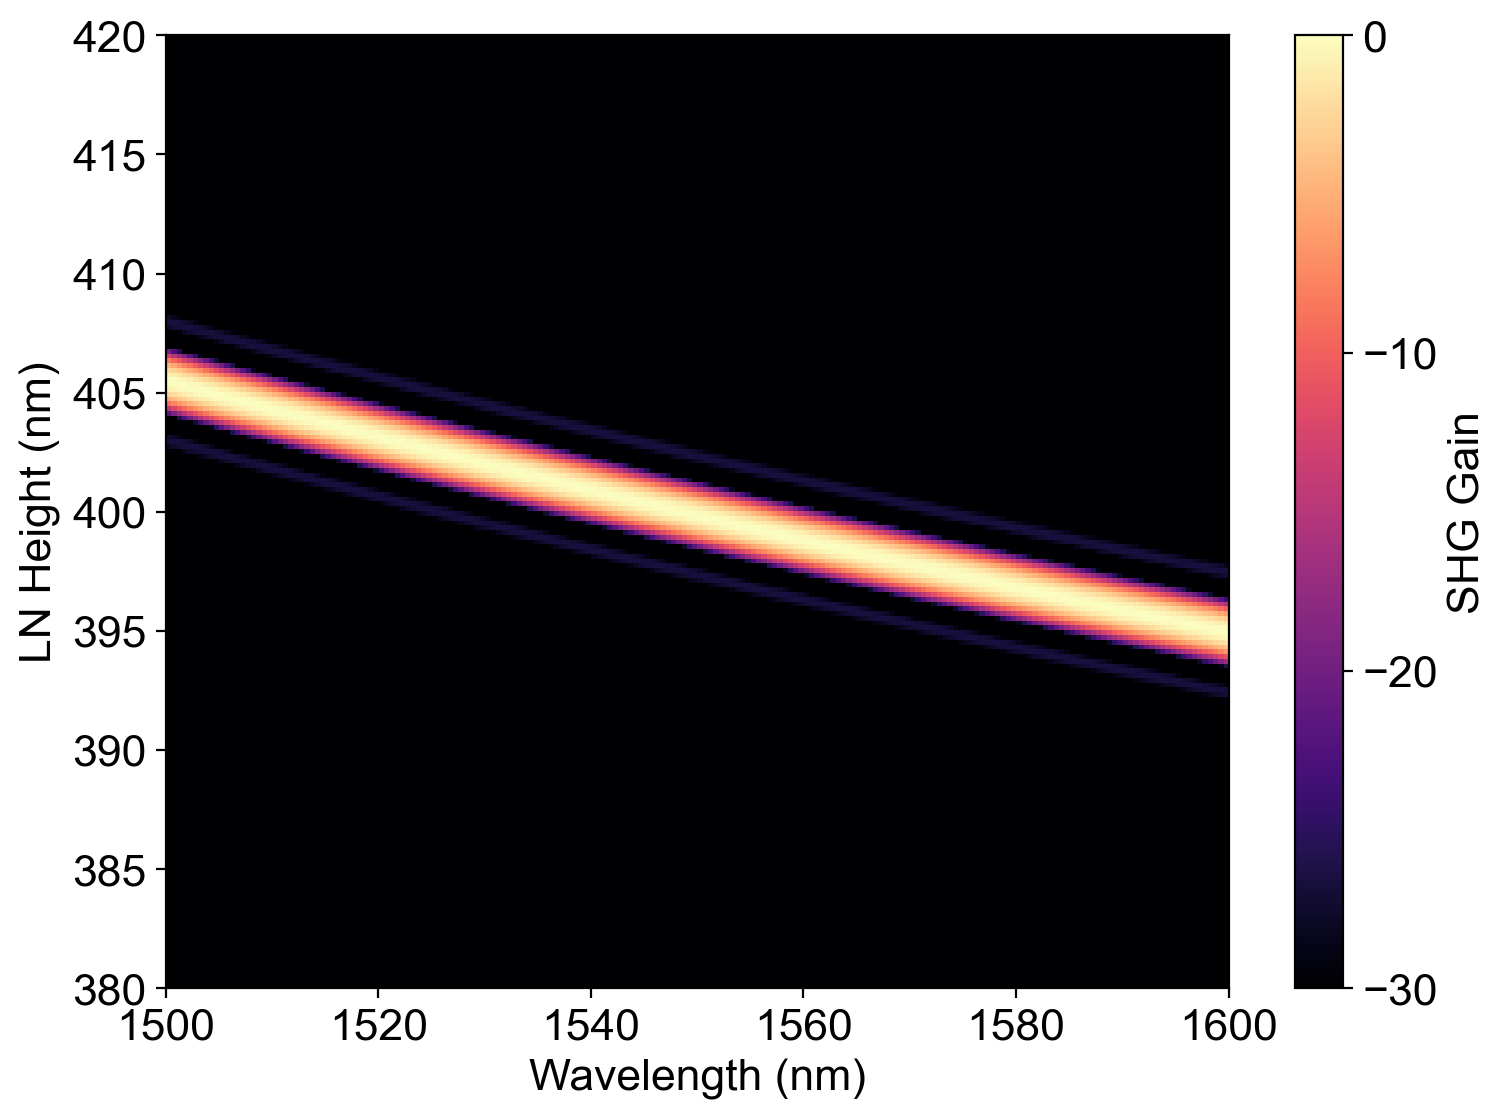

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 폰트 및 그래프 설정
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 20,         # 기본 글자 크기 설정
    'axes.titlesize': 18,    # 제목 글자 크기
    'axes.labelsize': 20,    # 축 레이블 크기
    'xtick.labelsize': 20,   # x축 눈금 크기
    'ytick.labelsize': 20    # y축 눈금 크기
})

# 플롯 생성
fig, ax = plt.subplots(figsize=(8, 6))

\

# imshow로 데이터 시각화 (색상 범위 제한)
im = ax.imshow(10 * np.log10(Gain_float), cmap='magma', aspect='auto', 
               extent=[fine_wavelength_set.min()*1e3, fine_wavelength_set.max()*1e3, 
                       fine_thickness_set.min()*1e3, fine_thickness_set.max()*1e3],
               origin='lower', vmin=-30, vmax=0)
#viridis
#viridis를 plasma, inferno, 또는 cividis
# 'viridis', 'coolwarm', 'cubehelix', 'Spectral'
# 색상바 추가 (범위가 0에서 -15로 설정된 색상바)
cbar = fig.colorbar(im, ticks=[0, -10, -20,-30])  # 지정된 범위 내의 틱만 표시
cbar.set_label('SHG Gain', fontsize=16)           # 색상바 레이블 설정
cbar.ax.tick_params(labelsize=16)                 # 색상바 눈금 크기 조정

# 그래프 레이블 및 제목 설정
ax.set_xlabel('Wavelength (nm)', fontsize=16)
ax.set_ylabel('LN Height (nm)', fontsize=16)
#ax.set_title('SHG gain with respect to Width and wavelength', fontsize=18)

# 눈금 크기 조정
ax.tick_params(axis='both', which='major', labelsize=16)

# 레이아웃 조정
plt.tight_layout()

# 그래프 보여주기
plt.show()
